# Reproducing Diebold-Yilmaz (2012)

In [16]:
import os
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

from pyconnectedness import static_connectedness, dynamic_connectedness

# paths below are relative to the repository root
while not os.path.isdir("examples") and os.path.basename(os.getcwd()):
    os.chdir("..")

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

In [8]:
raw_vola = pd.read_excel("examples/data/dy2012_vola.xlsx").set_index("date")
log_vola = np.log(raw_vola)

print("Assets:", list(log_vola.columns))
print("Observations:", len(log_vola), "| Missing:", int(log_vola.isna().sum().sum()))
print("Sample:", log_vola.index.min().date(), "->", log_vola.index.max().date())

Assets: ['sp500', 'r_10y', 'dj_ubs_com', 'usdx']
Observations: 2771 | Missing: 0
Sample: 1999-01-25 -> 2010-01-29


## Table 1 - Descriptive Statistics 

In [9]:
table1 = pd.DataFrame({
    "Mean":     log_vola.mean(),
    "Median":   log_vola.median(),
    "Maximum":  log_vola.max(),
    "Minimum":  log_vola.min(),
    "Std.Dev.": log_vola.std(ddof=1),
    "Skewness": pd.Series(stats.skew(log_vola, bias=True), index=log_vola.columns),
    "Kurtosis": pd.Series(stats.kurtosis(log_vola, fisher=False, bias=True), index=log_vola.columns),
}).T
table1.round(4)

,sp500,r_10y,dj_ubs_com,usdx
Mean,-9.7042,-9.4364,-10.6901,-11.0045
Median,-9.7430,-9.4389,-10.5025,-10.9901
Maximum,-5.4509,-4.2274,-6.3435,-7.6186
Minimum,-13.0902,-13.7876,-18.3283,-16.8633
Std.Dev.,1.1856,1.1921,1.5415,0.9765
Skewness,0.2143,0.0193,-0.7332,-0.2146
Kurtosis,3.1827,3.1595,4.2080,3.8725


## The generalized spillover index

will be updated

## Table 2 - Volatility spillover table, four asset classes

In [13]:
conn = static_connectedness (log_vola, horizon=10, method="generalized", lags=4)
print ("total volatility spillover index - pyconnectedness:", round(conn.total,2), "% (paper:12.6%)")

total volatility spillover index - pyconnectedness: 12.59 % (paper:12.6%)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [14]:
conn.table.round(2)

,sp500,r_10y,dj_ubs_com,usdx,FROM
sp500,88.76,7.29,0.35,3.61,11.24
r_10y,10.21,81.45,2.73,5.61,18.55
dj_ubs_com,0.47,3.70,93.69,2.14,6.31
usdx,5.69,7.03,1.55,85.73,14.27
TO,16.37,18.01,4.62,11.36,50.37
TO_incl_own,105.13,99.46,98.31,97.10,12.59
NET,5.13,-0.54,-1.69,-2.90,0.00


# Directional spillovers over time

In [18]:
dyn = dynamic_connectedness (log_vola, window = 200, horizon = 10, method = "generalized", lags =4)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarnin

In [19]:
N = len(dyn.names)
i_st = dyn.names.index("sp500")
i_bo = dyn.names.index("r_10y")
i_co = dyn.names.index("dj_ubs_com")
i_fx = dyn.names.index("usdx")

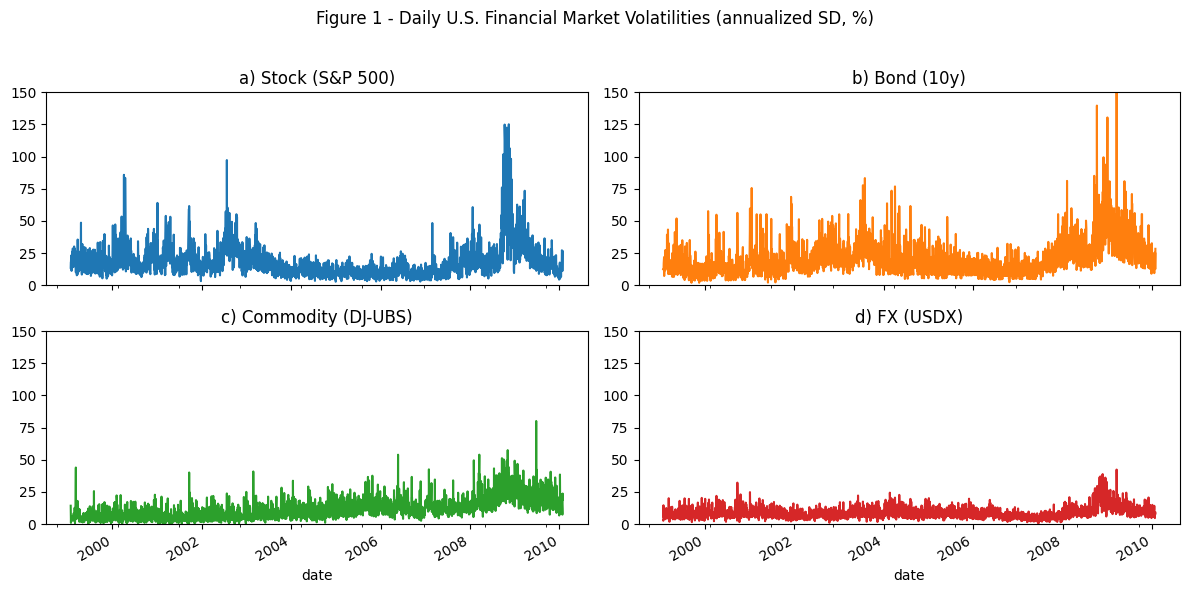

In [ ]:
# Fig 1 - daily vola (yearly SD, %)
annual_vol = 100 * np.sqrt(365 * raw_vola) # check 365 
annual_vol.plot(subplots=True, layout=(2, 2), figsize=(12, 6), legend=False, ylim=(0, 150),
                title=["a) Stock (S&P 500)", "b) Bond (10y)", "c) Commodity (DJ-UBS)", "d) FX (USDX)"])
plt.suptitle("Figure 1 - Daily U.S. Financial Market Volatilities (annualized SD, %)")
plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

In [22]:
dyn.directional_to

,sp500,r_10y,dj_ubs_com,usdx
date,,,,
1999-11-05,17.436208,19.732861,7.805228,9.050588
1999-11-08,17.172771,20.530437,8.401407,8.321232
1999-11-09,17.480696,20.310964,7.544346,7.342711
1999-11-10,17.677246,19.908660,7.513109,7.100182
1999-11-11,17.716967,18.620759,7.537469,7.962353
...,...,...,...,...
2010-01-25,28.461939,16.384165,8.320322,16.973936
2010-01-26,29.054159,17.460041,8.481066,17.998135
2010-01-27,28.746555,18.098451,8.760995,17.394980


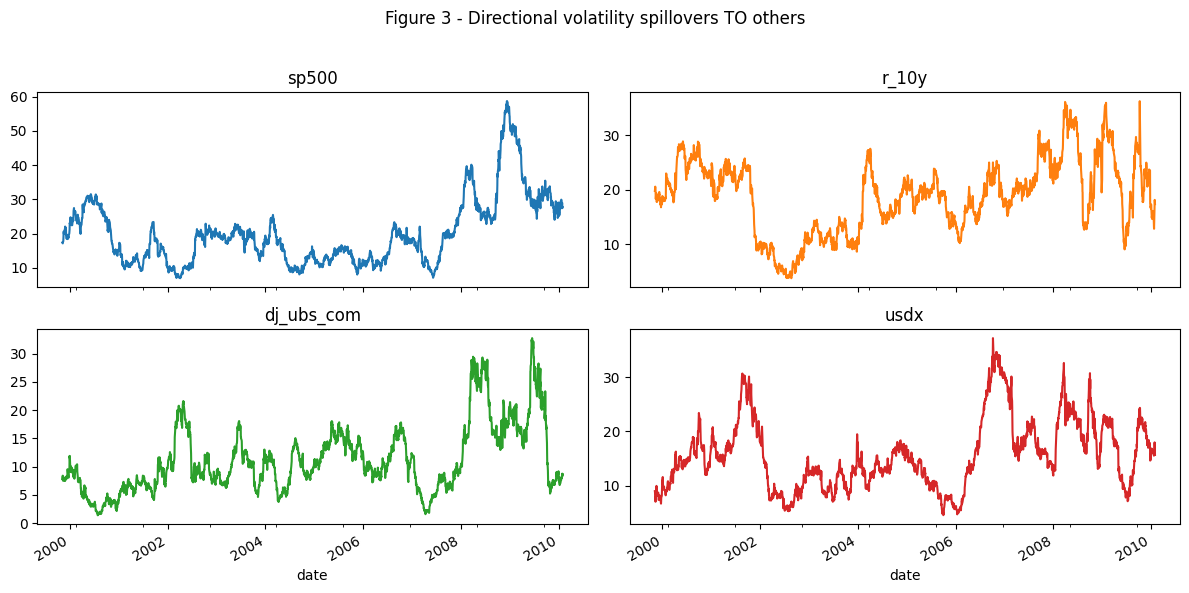

In [24]:
# Fig 3
(dyn.directional_to).plot(subplots=True, layout=(2, 2), figsize=(12, 6), legend=False,
                              title=list(dyn.directional_to.columns))
plt.suptitle("Figure 3 - Directional volatility spillovers TO others")
plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()


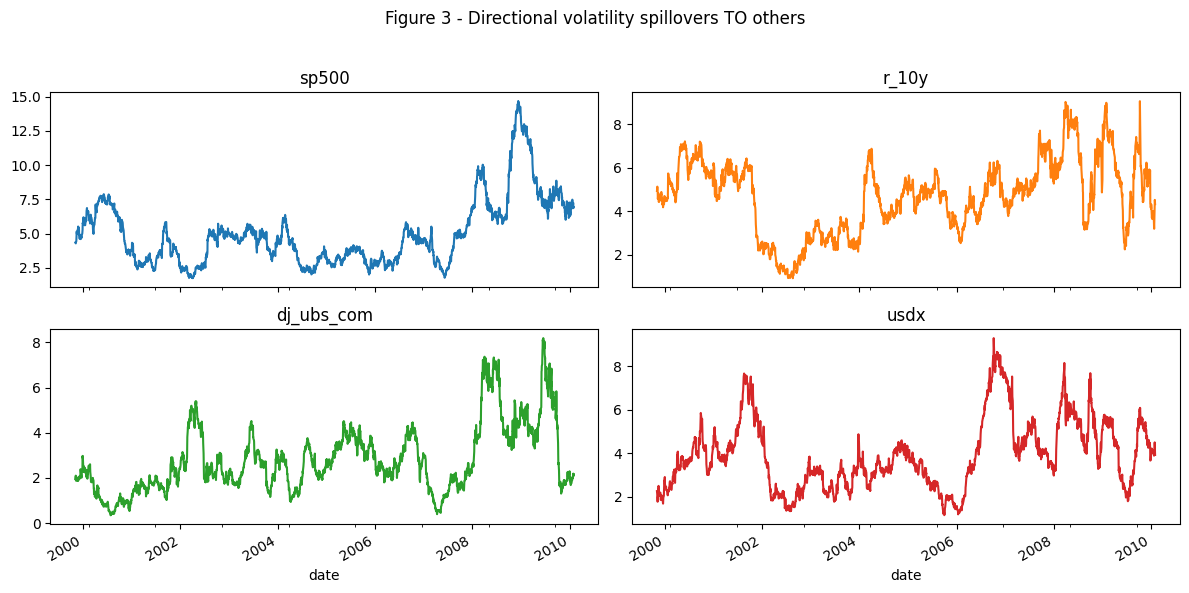

In [26]:
# Fig 3
(dyn.directional_to / N).plot(subplots=True, layout=(2, 2), figsize=(12, 6), legend=False,
                              title=list(dyn.directional_to.columns))
plt.suptitle("Figure 3 - Directional volatility spillovers TO others")
plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

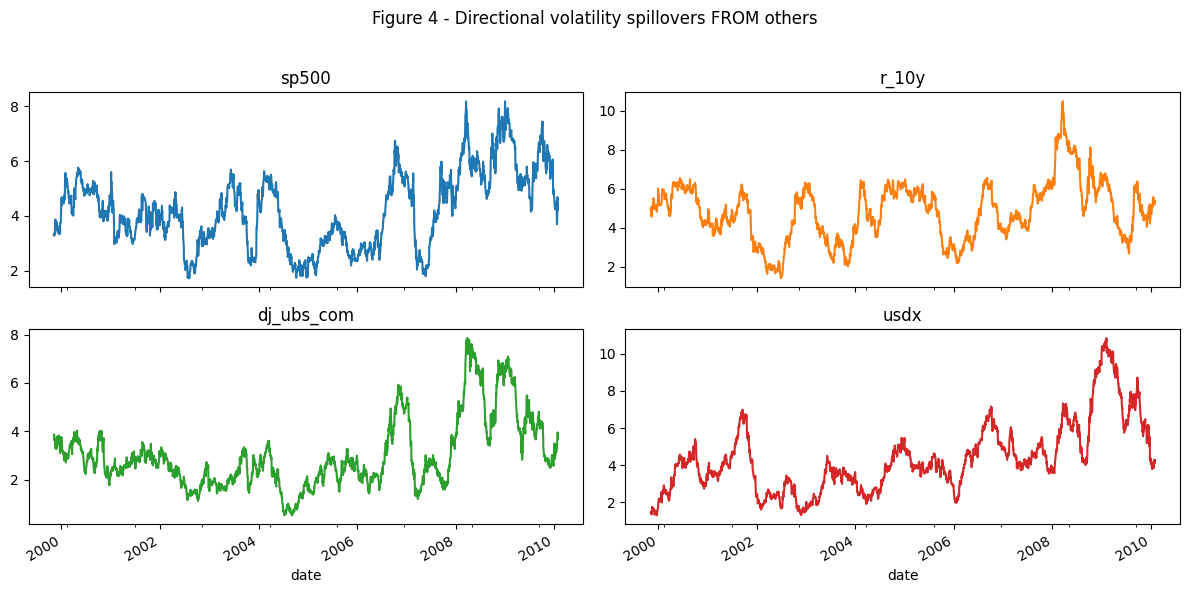

In [30]:
# Fig 4
(dyn.directional_from / N).plot(subplots=True, layout=(2, 2), figsize=(12, 6), legend=False,
                              title=list(dyn.directional_from.columns))
plt.suptitle("Figure 4 - Directional volatility spillovers FROM others")
plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

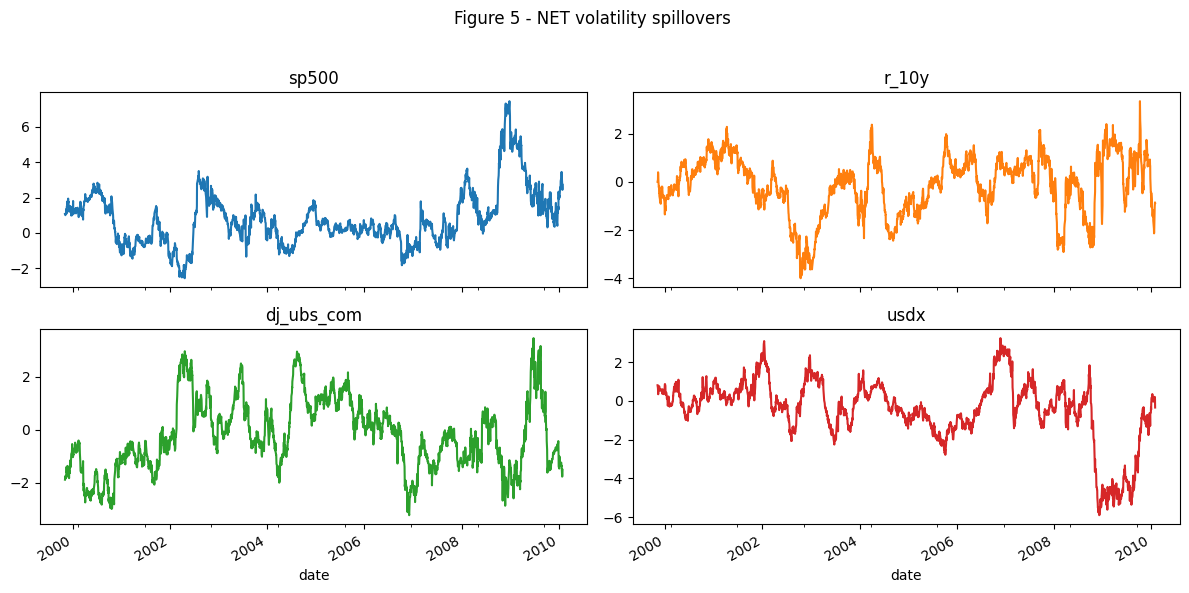

In [35]:
# Fig 5
(dyn.net / N).plot(subplots=True, layout=(2, 2), figsize=(12, 6), legend=False,
                              title=list(dyn.net.columns))
plt.suptitle("Figure 5 - NET volatility spillovers ")
plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

## NET pairwise spillovers

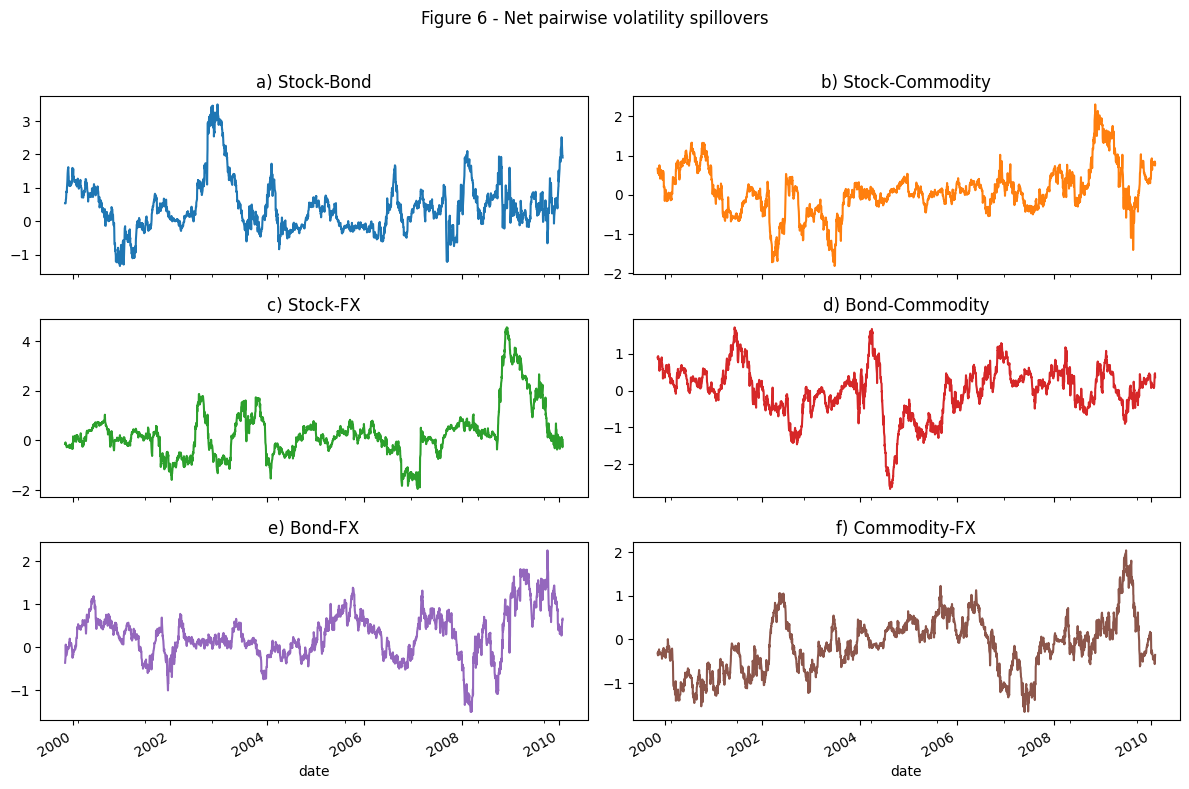

In [38]:
# Figure 6 - Net Pairwise Spillovers (alle 6 Paare). Vorzeichen: positiv = der erstgenannte Markt ist Netto-Sender
net_pairwise = pd.DataFrame({
    "a) Stock-Bond":      dyn.fevd[:, i_bo, i_st] - dyn.fevd[:, i_st, i_bo],
    "b) Stock-Commodity": dyn.fevd[:, i_co, i_st] - dyn.fevd[:, i_st, i_co],
    "c) Stock-FX":        dyn.fevd[:, i_fx, i_st] - dyn.fevd[:, i_st, i_fx],
    "d) Bond-Commodity":  dyn.fevd[:, i_co, i_bo] - dyn.fevd[:, i_bo, i_co],
    "e) Bond-FX":         dyn.fevd[:, i_fx, i_bo] - dyn.fevd[:, i_bo, i_fx],
    "f) Commodity-FX":    dyn.fevd[:, i_fx, i_co] - dyn.fevd[:, i_co, i_fx],
}, index=dyn.total.index) / N
net_pairwise.plot(subplots=True, layout=(3, 2), figsize=(12, 8), legend=False,
                  title=list(net_pairwise.columns))
plt.suptitle("Figure 6 - Net pairwise volatility spillovers")
plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()